<a href="https://colab.research.google.com/github/JaniVarga/Arduino_BMP_280/blob/main/Skin_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin segmentation with different technic




## Skin detection in different color spaces with thresholds

Sources: https://arxiv.org/pdf/1708.02694

In [1]:
# Imports
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Setup image path
img_1_path = "/content/1728293261557.jpeg"
img_2_path = "/content/1728293261563.jpg"
img_3_path = "/content/X25mc.jpg"

In [3]:
# Open images with PIL
with Image.open(img_1_path) as img_1:
  img_1.load()

with Image.open(img_2_path) as img_2:
  img_2.load()

with Image.open(img_3_path) as img_3:
  img_3.load()

In [4]:
# Images are in "RGB" mode
img_1.mode, img_2.mode, img_3.mode, img_1.size, img_2.size, img_3.size

('RGB', 'RGB', 'RGB', (1080, 1920), (3472, 4640), (560, 600))

In [5]:
# Resize the image
img_1 = img_1.reduce(4)
img_2 = img_2.reduce(4)
img_3 = img_3.reduce(2)
img_1.size, img_2.size, img_3.size

((270, 480), (868, 1160), (280, 300))

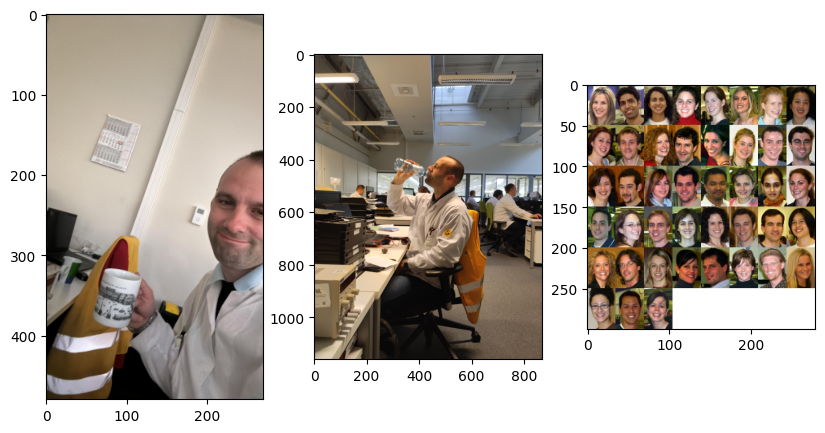

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(img_1)
ax[1].imshow(img_2)
ax[2].imshow(img_3)

plt.show()

### Skin detection in RGB color space.

In [7]:
def rgb_channels(image):
  """
  Split RGB image into R, G, B channels.
  """
  # Convert PIL Image to numpy array
  image = np.array(image)
  # Get R, G, B components
  r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]

  return r, g, b

In [8]:
red_channel, green_channel, blue_channel = rgb_channels(img_1)

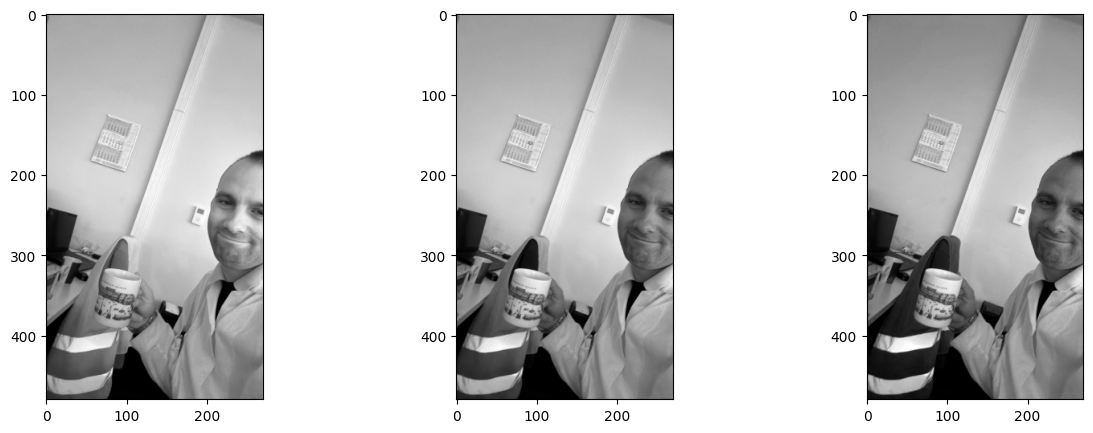

In [9]:
# Visualize Red,Green,Blue color channels
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(red_channel, cmap='gray')
ax[1].imshow(green_channel, cmap='gray')
ax[2].imshow(blue_channel, cmap='gray')

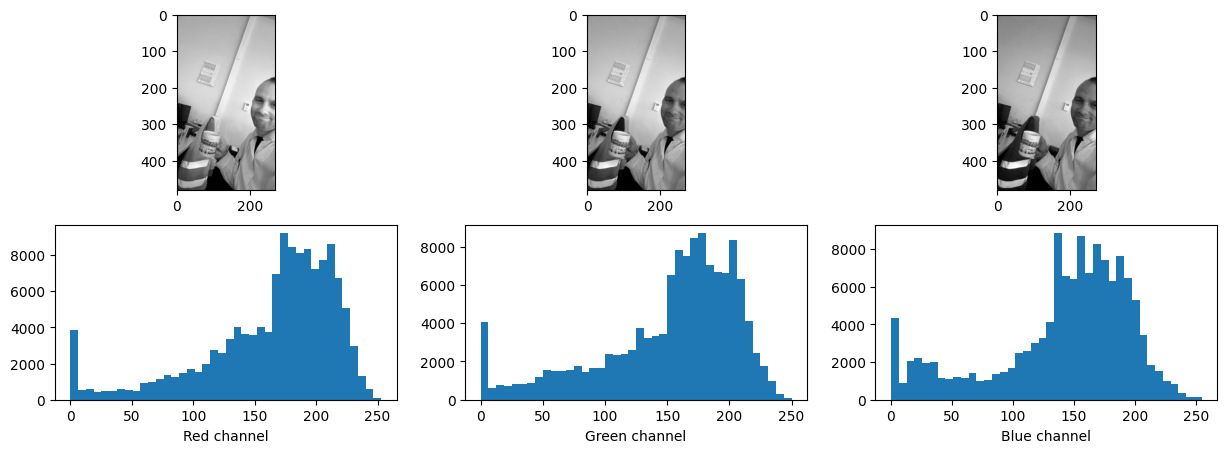

In [10]:
fig, ax = plt.subplots(2,3, figsize=(15,5))

ax[0,0].imshow(red_channel, cmap='gray')
ax[0,1].imshow(green_channel, cmap='gray')
ax[0,2].imshow(blue_channel, cmap='gray')
ax[1, 0].hist(red_channel.ravel(), bins=40, range=(red_channel.min(), red_channel.max()))
ax[1, 0].set_xlabel('Red channel')
ax[1, 1].hist(green_channel.ravel(), bins=40, range=(green_channel.min(), green_channel.max()))
ax[1, 1].set_xlabel('Green channel')
ax[1, 2].hist(blue_channel.ravel(), bins=40, range=(blue_channel.min(), blue_channel.max()))
ax[1, 2].set_xlabel('Blue channel')

plt.show()

In [11]:
face_red = red_channel[200:310, 220:270]
face_green = green_channel[200:310, 220:270]
face_blue = blue_channel[200:310, 220:270]

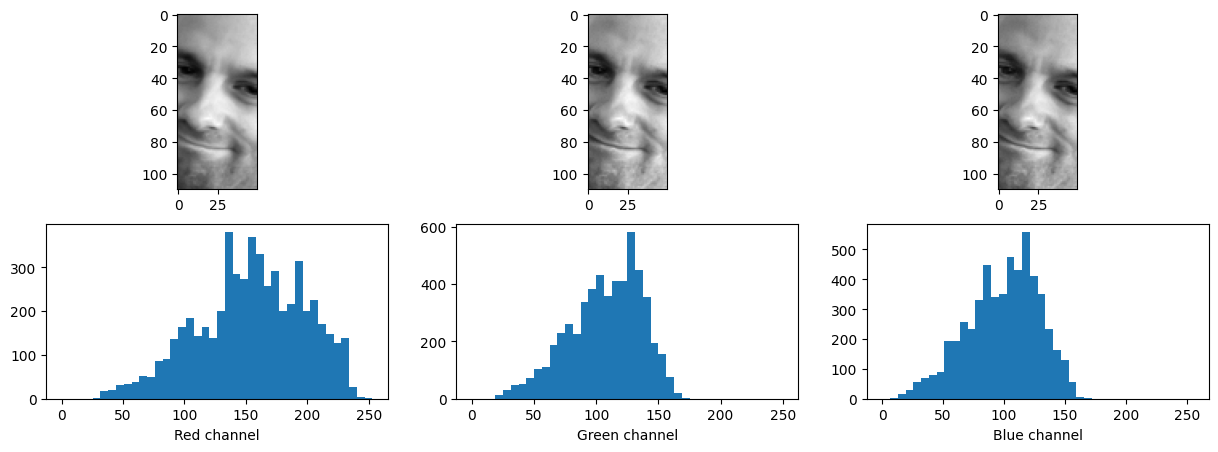

In [12]:
fig, ax = plt.subplots(2,3, figsize=(15,5))

ax[0,0].imshow(face_red, cmap='gray')
ax[0,1].imshow(face_green, cmap='gray')
ax[0,2].imshow(face_blue, cmap='gray')
ax[1, 0].hist(face_red.ravel(), bins=40, range=(red_channel.min(), red_channel.max()))

ax[1, 0].set_xlabel('Red channel')
ax[1, 1].hist(face_green.ravel(), bins=40, range=(green_channel.min(), green_channel.max()))
ax[1, 1].set_xlabel('Green channel')
ax[1, 2].hist(face_blue.ravel(), bins=40, range=(blue_channel.min(), blue_channel.max()))
ax[1, 2].set_xlabel('Blue channel')

plt.show()

In [13]:
face_red.min(), face_red.max(), face_green.min(), face_green.max(), face_blue.min(), face_blue.max()

(31, 249, 19, 169, 10, 169)

In [14]:
low_color = (31,19,10)
up_color = (249,169,169)

In [18]:
def make_mask(image ,light_color, dark_color):
  mask_h = np.array([255 if light_color[0] <= x <= dark_color[0] else 0 for x in np.nditer(red_channel)]).reshape(image.height, image.width)
  mask_s = np.array([255 if light_color[1] <= x <= dark_color[1] else 0 for x in np.nditer(green_channel)]).reshape(image.height, image.width)
  mask_v = np.array([255 if light_color[2] <= x <= dark_color[2] else 0 for x in np.nditer(blue_channel)]).reshape(image.height, image.width)
  logical_mask = np.logical_and(np.logical_and(mask_h, mask_s), mask_v)
  mask = np.array([255 if x == True else 0 for x in np.nditer(logical_mask)]).reshape(image.height, image.width)

  return mask, mask_h, mask_s, mask_v

In [19]:
mask_rgb, mask_r, mask_g, mask_b = make_mask(img_1, low_color, up_color)

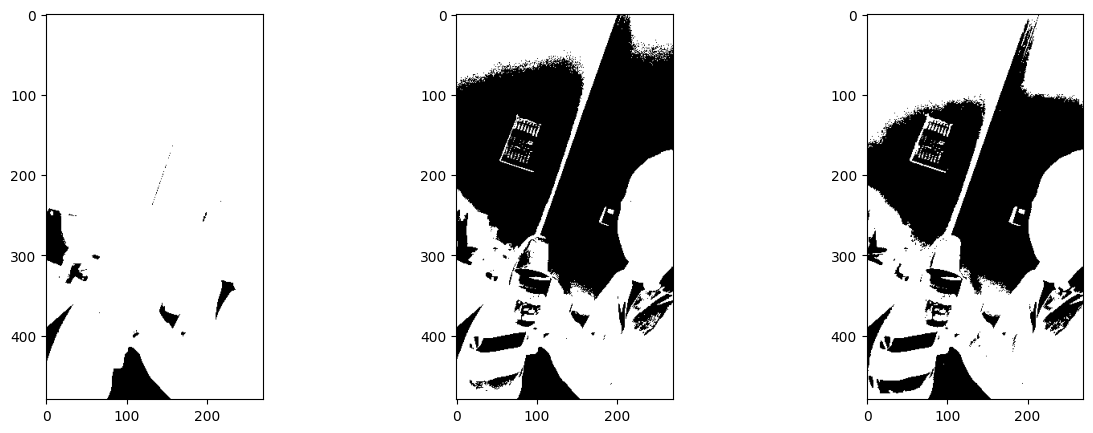

In [20]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(mask_r, cmap='gray', vmin=0, vmax=255)
ax[1].imshow(mask_g, cmap='gray', vmin=0, vmax=255)
ax[2].imshow(mask_b, cmap='gray', vmin=0, vmax=255)  # vmin=0, vmax=255 settings to show white pictures in

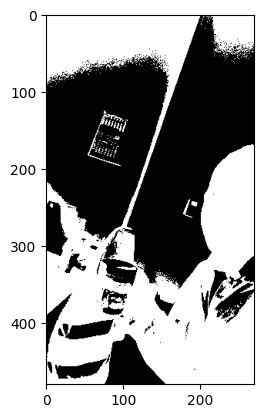

In [21]:
# Visualize the mask
plt.imshow(mask_rgb, cmap='gray')

In [22]:
def use_the_mask(image_to_customize, mask):
  for i in range(mask.shape[0]):
    for j in range(mask.shape[1]):
      if mask[i,j] == 0:
        image_to_customize.putpixel((j,i), (0,0,0))
  return image_to_customize

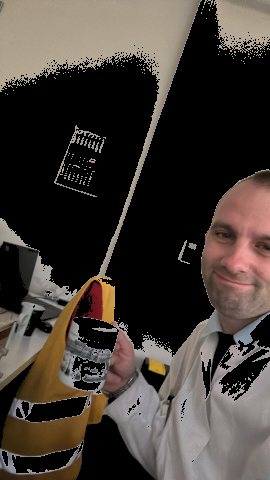

In [23]:
rgb_mask = use_the_mask(img_1, mask_rgb)
rgb_mask

###  Skin detection in HSV color space.

The HSV color space is more intuitive to how people experience color than the RGB color space. As hue (H)
varies from 0 to 1.0, the corresponding colors vary from red, through yellow, green, cyan, blue, and magenta,
back to red. As saturation(S) varies from 0 to 1.0, the corresponding colors (hues) vary from unsaturated
(shades of gray) to fully saturated (no white component). As value (V), or brightness, varies from 0 to 1.0, the
corresponding colors become increasingly brighter. The hue component in HSV is in the range 0° to 360° angle
all lying around a hexagon as shown figure 3 [3].




In [24]:
# Make a function to convert RGB -> H, S, V channels
def rgb_to_hsv(image):
  """
  Convert RGB image to HSV color space.
  """
  # 0.Convert "JpegImageFile" to numpy array
  image = np.array(image)
  # 1. Calculate R' = R/255, G' = G/255, B' = B/255
  image = image / 255
  # 2. Calculate the delta c_max - c_min
  c_max = np.max(image, axis=2)
  c_min = np.min(image, axis=2)
  delta = c_max - c_min
  # 3. Hue calculation
  hue = []
  for i, row in enumerate(image):
    for j, pixel in enumerate(row):
      if delta[i,j] == 0:
        hue.append(0)
      elif c_max[i,j] == pixel[0]:
        hue.append(((pixel[1] - pixel[2])/delta[i,j])%6)
      elif c_max[i,j] == pixel[1]:
        hue.append(2 + (pixel[2] - pixel[0])/delta[i,j])
      elif c_max[i,j] == pixel[2]:
        hue.append(4 + (pixel[0] - pixel[1])/delta[i,j])
      else:
        hue.append(0)

  hue = np.array(hue).reshape(image.shape[0], image.shape[1])
  hue = hue * 60
  # 4. Calculate saturation
  saturation = []
  for i, row in enumerate(image):
    for j, pixel in enumerate(row):
      saturation.append(0 if c_max[i,j] == 0 else (delta[i,j] / c_max[i,j]) * 100)

  saturation = np.array(saturation).reshape(image.shape[0], image.shape[1])
  # 5. Calculate value
  value = []
  for i, row in enumerate(image):
    for j, pixel in enumerate(row):
      value.append(c_max[i,j] * 100)

  value = np.array(value).reshape(image.shape[0], image.shape[1])

  return hue, saturation, value

In [25]:
h, s, v = rgb_to_hsv(img_1) # h -> 0 - 360° | s: 0 - 100 % | v 0 - 100%

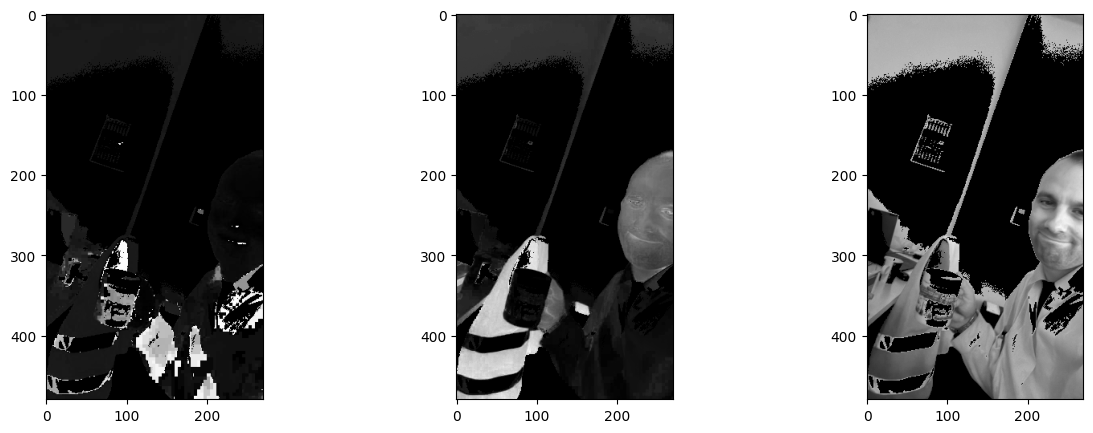

In [26]:
# Visualize H,S,V color channels
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(h, cmap='gray')
ax[1].imshow(s, cmap='gray')
ax[2].imshow(v, cmap='gray')

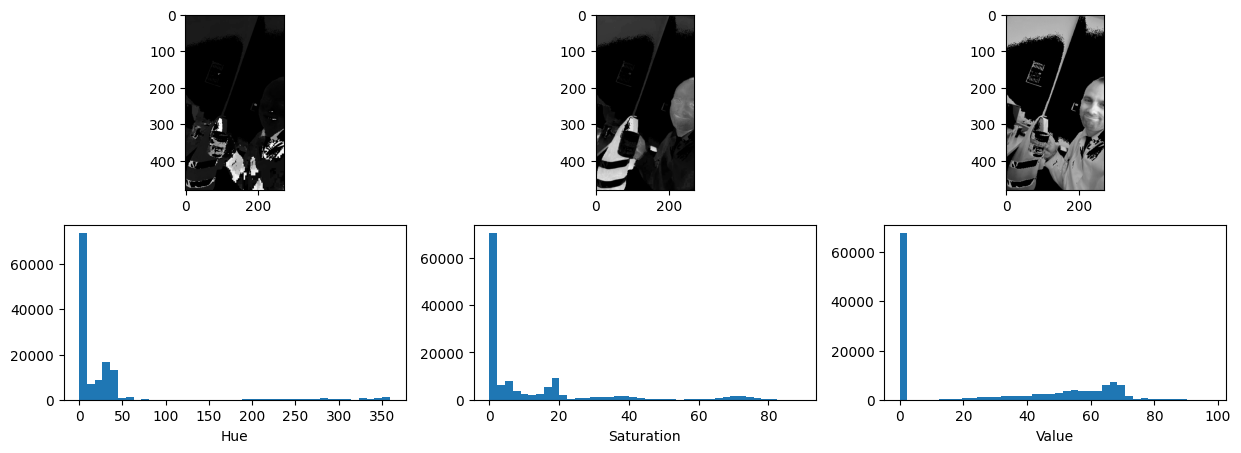

In [27]:
fig, ax = plt.subplots(2,3, figsize=(15,5))

ax[0,0].imshow(h, cmap='gray')
ax[0,1].imshow(s, cmap='gray')
ax[0,2].imshow(v, cmap='gray')
ax[1, 0].hist(h.ravel(), bins=40, range=(h.min(), h.max()))
ax[1, 0].set_xlabel('Hue')
ax[1, 1].hist(s.ravel(), bins=40, range=(s.min(), s.max()))
ax[1, 1].set_xlabel('Saturation')
ax[1, 2].hist(v.ravel(), bins=40, range=(v.min(), v.max()))
ax[1, 2].set_xlabel('Value')

plt.show()

In [28]:
face_h = h[200:310, 220:270]
face_s = s[200:310, 220:270]
face_v = v[200:310, 220:270]

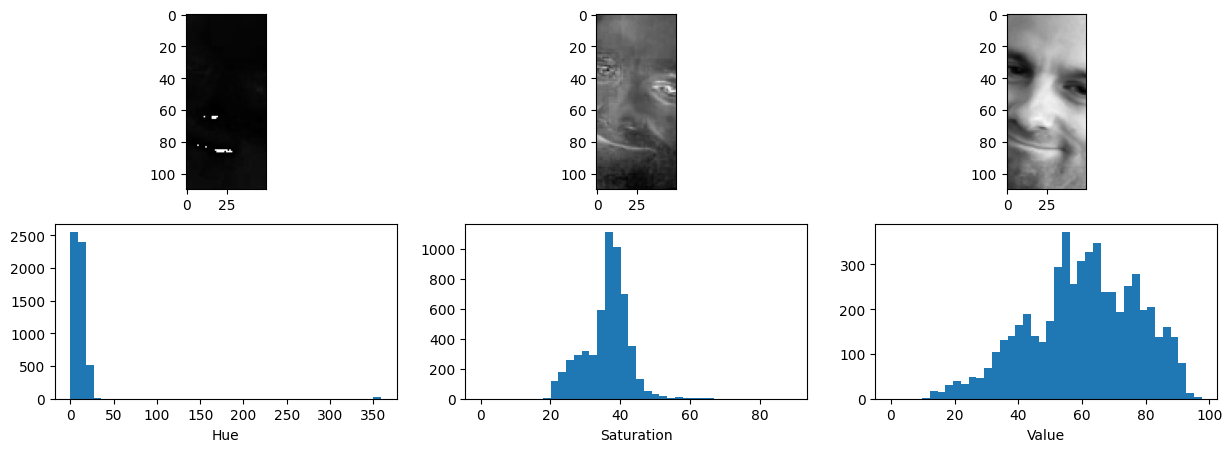

In [29]:
fig, ax = plt.subplots(2,3, figsize=(15,5))

ax[0,0].imshow(face_h, cmap='gray')
ax[0,1].imshow(face_s, cmap='gray')
ax[0,2].imshow(face_v, cmap='gray')
ax[1, 0].hist(face_h.ravel(), bins=40, range=(h.min(), h.max()))
ax[1, 0].set_xlabel('Hue')
ax[1, 1].hist(face_s.ravel(), bins=40, range=(s.min(), s.max()))
ax[1, 1].set_xlabel('Saturation')
ax[1, 2].hist(face_v.ravel(), bins=40, range=(v.min(), v.max()))
ax[1, 2].set_xlabel('Value')

plt.show()

In [30]:
light_skin_tone_hsv = (0, 28, 0)
dark_skin_tone_hsv = (25, 68, 100)

In [31]:
def make_mask(image ,light_color, dark_color):
  mask_h = np.array([255 if light_color[0] <= x <= dark_color[0] else 0 for x in np.nditer(h)]).reshape(image.height, image.width)
  mask_s = np.array([255 if light_color[1] <= x <= dark_color[1] else 0 for x in np.nditer(s)]).reshape(image.height, image.width)
  mask_v = np.array([255 if light_color[2] <= x <= dark_color[2] else 0 for x in np.nditer(v)]).reshape(image.height, image.width)
  logical_mask = np.logical_and(np.logical_and(mask_h, mask_s), mask_v)
  mask = np.array([255 if x == True else 0 for x in np.nditer(logical_mask)]).reshape(image.height, image.width)

  return mask, mask_h, mask_s, mask_v

In [32]:
mask_hsv, mask_h, mask_s, mask_v = make_mask(img_1, light_skin_tone_hsv, dark_skin_tone_hsv)

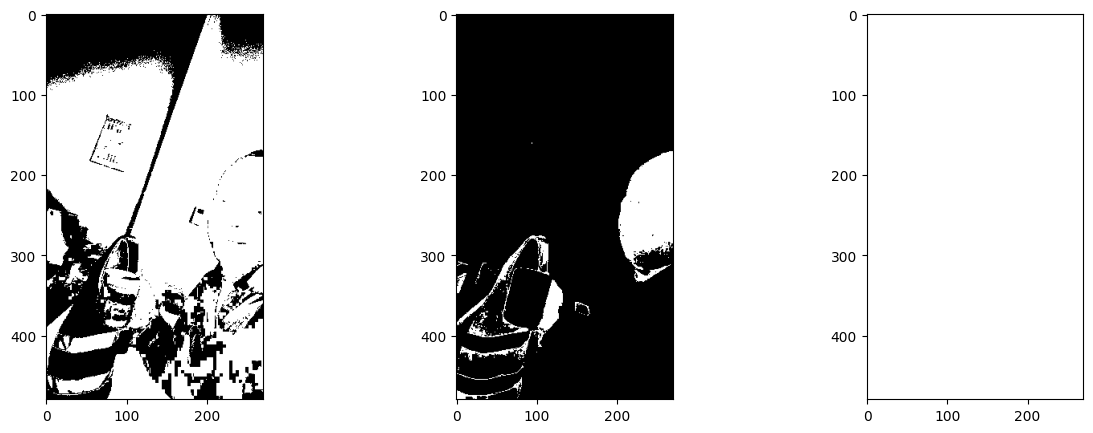

In [33]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(mask_h, cmap='gray', vmin=0, vmax=255)
ax[1].imshow(mask_s, cmap='gray', vmin=0, vmax=255)
ax[2].imshow(mask_v, cmap='gray', vmin=0, vmax=255)  # vmin=0, vmax=255 settings to show white pictures in

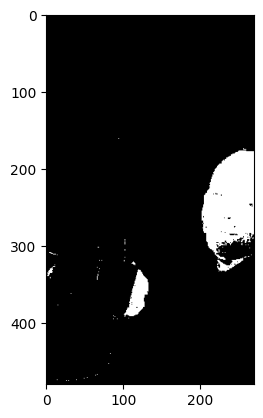

In [34]:
# Visualize the mask
plt.imshow(mask_hsv, cmap='gray')

In [35]:
def use_the_mask(image_to_customize, mask):
  for i in range(mask.shape[0]):
    for j in range(mask.shape[1]):
      if mask[i,j] == 0:
        image_to_customize.putpixel((j,i), (0,0,0))
  return image_to_customize

In [36]:
image_1 = img_1

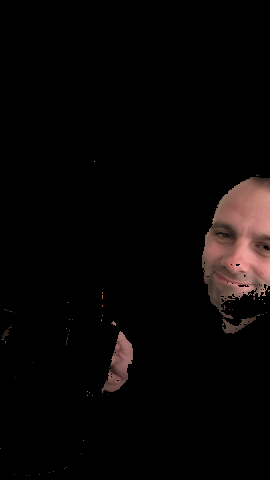

In [37]:
hsv_mask = use_the_mask(image_1, mask_hsv)
hsv_mask

## YIQ color space

In the YIQ color space Y component represent the intensity, the I and Q component represents the color information

In [38]:
with Image.open(img_1_path) as img_1:
  img_1.load()

In [39]:
img_1 = img_1.reduce(4)

In [40]:
def rgb_to_yiq(image):
  """
  Convert RGB image to YIQ color space.
  """
  # Convert PIL Image to numpy array
  image = np.array(image)
  # Get R, G, B components
  r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
  # Calculate Y, I, Q components
  y = 0.299*r + 0.587*g + 0.114*b
  i = 0.596*r - 0.275*g - 0.321*b
  q = 0.212*r - 0.523*g + 0.311*b
  # Return Y, I, Q components
  return y, i, q

In [41]:
y, i, q = rgb_to_yiq(img_1)

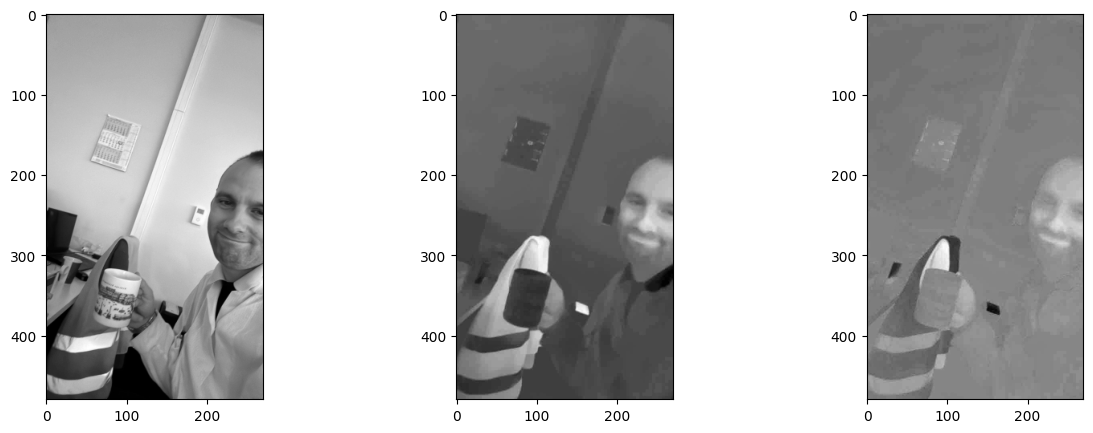

In [42]:
# Show y, i, q
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(y, cmap='gray')
ax[1].imshow(i, cmap='gray')
ax[2].imshow(q, cmap='gray')

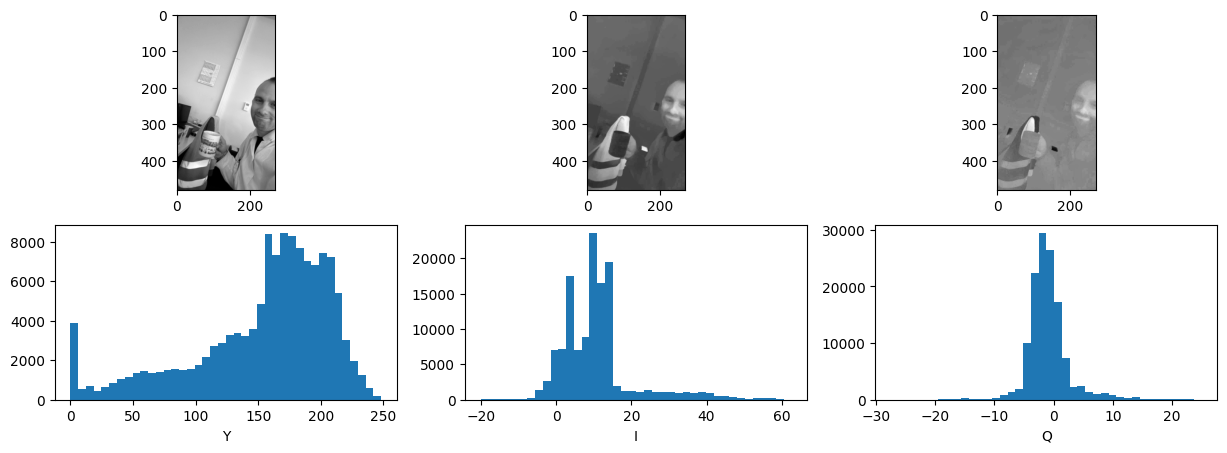

In [43]:
fig, ax = plt.subplots(2,3, figsize=(15,5))

ax[0,0].imshow(y, cmap='gray')
ax[0,1].imshow(i, cmap='gray')
ax[0,2].imshow(q, cmap='gray')
ax[1, 0].hist(y.ravel(), bins=40, range=(y.min(), y.max()))
ax[1, 0].set_xlabel('Y')
ax[1, 1].hist(i.ravel(), bins=40, range=(i.min(), i.max()))
ax[1, 1].set_xlabel('I')
ax[1, 2].hist(q.ravel(), bins=40, range=(q.min(), q.max()))
ax[1, 2].set_xlabel('Q')

plt.show()

In [44]:
face_y = y[200:310, 220:270]
face_i = i[200:310, 220:270]
face_q = q[200:310, 220:270]

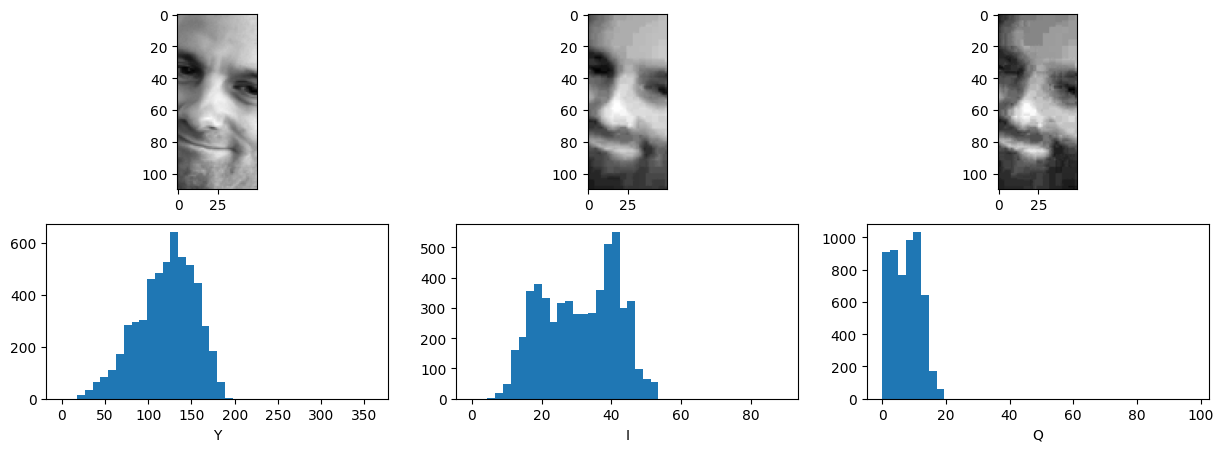

In [45]:
fig, ax = plt.subplots(2,3, figsize=(15,5))

ax[0,0].imshow(face_y, cmap='gray')
ax[0,1].imshow(face_i, cmap='gray')
ax[0,2].imshow(face_q, cmap='gray')
ax[1, 0].hist(face_y.ravel(), bins=40, range=(h.min(), h.max()))
ax[1, 0].set_xlabel('Y')
ax[1, 1].hist(face_i.ravel(), bins=40, range=(s.min(), s.max()))
ax[1, 1].set_xlabel('I')
ax[1, 2].hist(face_q.ravel(), bins=40, range=(v.min(), v.max()))
ax[1, 2].set_xlabel('Q')

plt.show()

In [46]:
face_y.min(), face_y.max(), face_i.min(), face_i.max(),face_q.min(), face_q.max()

(21.561999999999998,
 192.92,
 6.6019999999999985,
 53.09,
 -1.612000000000001,
 18.345)

In [47]:
light_skin_tone_yiq = (21, 6, 0)
dark_skin_tone_yiq = (190 , 53, 18)

In [48]:
def make_mask(image ,light_color, dark_color):
  """
  Creates a mask for skin tones based on YIQ color space.

  Args:
      image: The input image.
      light_color: The YIQ values for the light skin tone.
      dark_color: The YIQ values for the dark skin tone.

  Returns:
      A binary mask where skin tones are white (255) and other areas are black (0).
  """
  # Convert image to YIQ color space
  y, i, q = rgb_to_yiq(image)

  # Create the mask based on YIQ values
  # Note: Reshape is applied before converting to numpy array, ensuring correct dimensions
  mask_y = np.array([255 if light_color[0] <= x <= dark_color[0] else 0 for x in y.reshape(-1)]).reshape(image.height, image.width)
  mask_i = np.array([255 if light_color[1] <= x <= dark_color[1] else 0 for x in i.reshape(-1)]).reshape(image.height, image.width)
  mask_q = np.array([255 if light_color[2] <= x <= dark_color[2] else 0 for x in q.reshape(-1)]).reshape(image.height, image.width)

  # Combine the masks for each channel
  mask = mask_y & mask_i & mask_q

  return mask

In [49]:
mask_yiq = make_mask(img_1, light_skin_tone_yiq, dark_skin_tone_yiq)

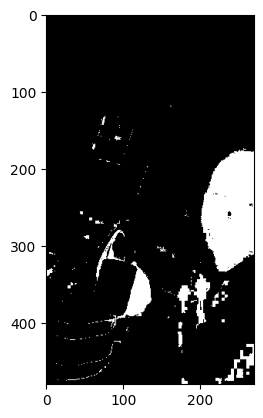

In [50]:
# Visualize the mask
plt.imshow(mask_yiq, cmap='gray')

In [51]:
def use_the_mask(image, mask):
  for i in range(mask.shape[0]):
    for j in range(mask.shape[1]):
      if mask[i,j] == 0:
        image.putpixel((j,i), (0,0,0))
  return image

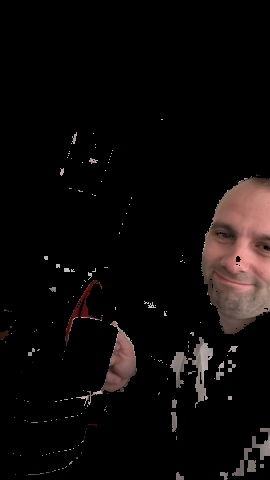

In [52]:
yiq_mask = use_the_mask(img_1, mask_yiq)
yiq_mask

## Skin detection in YCbCr color space

In [53]:
with Image.open(img_1_path) as img_1:
  img_1.load()

In [54]:
img_1 = img_1.reduce(4)

In [55]:
def rgb_to_ycbcr(image):

  image = np.array(image)
  r,g,b = image[:,:,0], image[:,:,1], image[:,:,2]

  y = 0.299*r + 0.587*g + 0.114*b
  cb = 128 - 0.168736*r - 0.3312*g + 0.500*b
  cr = 128 + 0.5*r - 0.4186*g - 0.081*b

  y = y.astype(np.uint8)
  cb = cb.astype(np.uint8)
  cr = cr.astype(np.uint8)

  return y, cb, cr

In [56]:
y_, cb, cr = rgb_to_ycbcr(img_1)

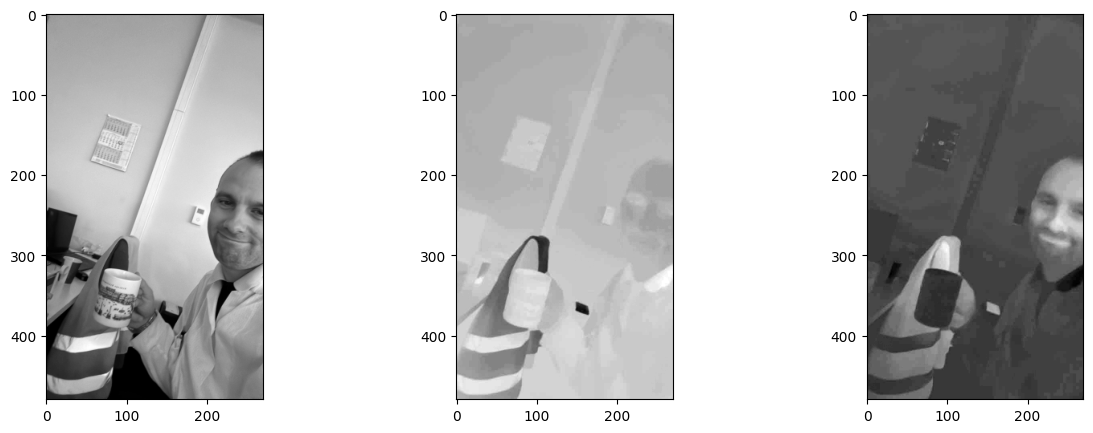

In [57]:
# Show y, cb, cr
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(y_, cmap='gray')
ax[1].imshow(cb, cmap='gray')
ax[2].imshow(cr, cmap='gray')

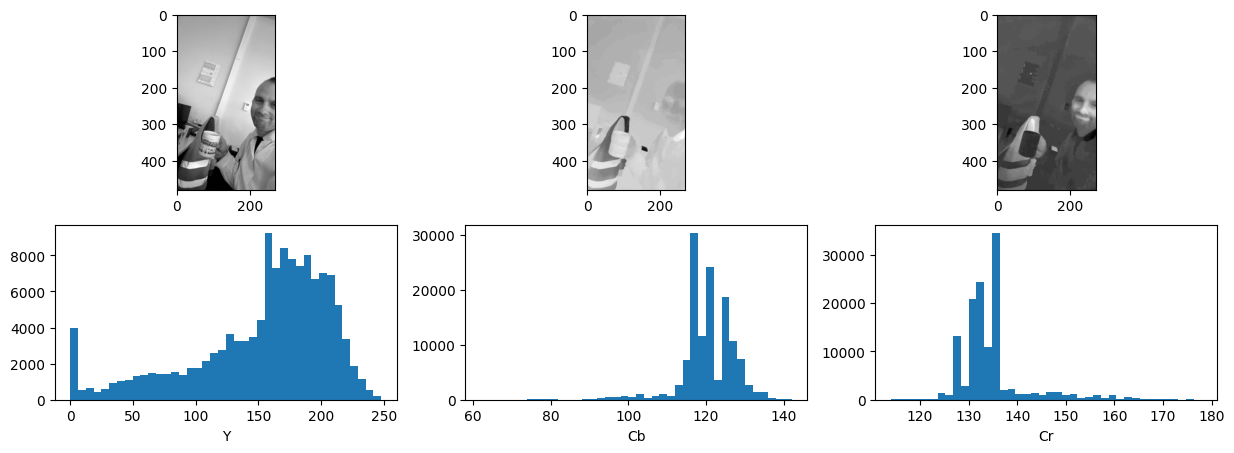

In [58]:
fig, ax = plt.subplots(2,3, figsize=(15,5))

ax[0,0].imshow(y_, cmap='gray')
ax[0,1].imshow(cb, cmap='gray')
ax[0,2].imshow(cr, cmap='gray')
ax[1, 0].hist(y_.ravel(), bins=40, range=(y_.min(), y_.max()))
ax[1, 0].set_xlabel('Y')
ax[1, 1].hist(cb.ravel(), bins=40, range=(cb.min(), cb.max()))
ax[1, 1].set_xlabel('Cb')
ax[1, 2].hist(cr.ravel(), bins=40, range=(cr.min(), cr.max()))
ax[1, 2].set_xlabel('Cr')

plt.show()

In [59]:
face_y_ = y_[200:310, 220:270]
face_cb = cb[200:310, 220:270]
face_cr = cr[200:310, 220:270]

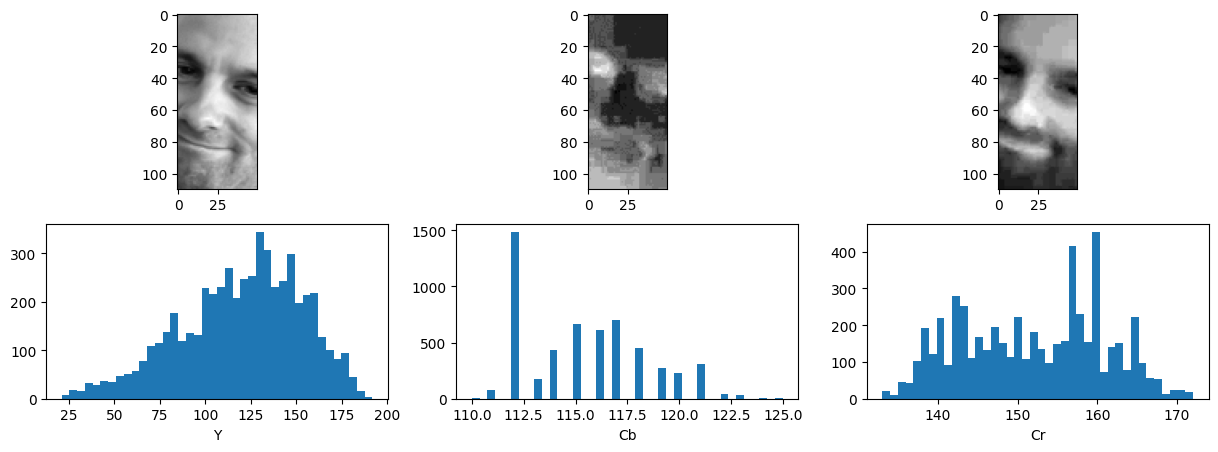

In [60]:
fig, ax = plt.subplots(2,3, figsize=(15,5))

ax[0,0].imshow(face_y_, cmap='gray')
ax[0,1].imshow(face_cb, cmap='gray')
ax[0,2].imshow(face_cr, cmap='gray')
ax[1, 0].hist(face_y_.ravel(), bins=40, range=(face_y_.min(), face_y_.max()))
ax[1, 0].set_xlabel('Y')
ax[1, 1].hist(face_cb.ravel(), bins=40, range=(face_cb.min(), face_cb.max()))
ax[1, 1].set_xlabel('Cb')
ax[1, 2].hist(face_cr.ravel(), bins=40, range=(face_cr.min(), face_cr.max()))
ax[1, 2].set_xlabel('Cr')

plt.show()

In [61]:
face_y_.min(), face_y_.max(), face_cb.min(), face_cb.max(),face_cr.min(), face_cr.max()

(21, 192, 110, 125, 133, 172)

In [62]:
light_skin_tone_ycbcr = (21, 110, 133)
dark_skin_tone_ycbcr = (192 , 125, 172)

In [63]:
def make_mask(image ,light_color, dark_color):
  mask_h = np.array([255 if light_color[0] <= x <= dark_color[0] else 0 for x in np.nditer(y_)]).reshape(image.height, image.width)
  mask_s = np.array([255 if light_color[1] <= x <= dark_color[1] else 0 for x in np.nditer(cb)]).reshape(image.height, image.width)
  mask_v = np.array([255 if light_color[2] <= x <= dark_color[2] else 0 for x in np.nditer(cr)]).reshape(image.height, image.width)
  logical_mask = np.logical_and(np.logical_and(mask_h, mask_s), mask_v)
  mask = np.array([255 if x == True else 0 for x in np.nditer(logical_mask)]).reshape(image.height, image.width)

  return mask, mask_h, mask_s, mask_v

In [64]:
mask_ycbcr, mask_y_, mask_cb, mask_cr = make_mask(img_1, light_skin_tone_ycbcr, dark_skin_tone_ycbcr)

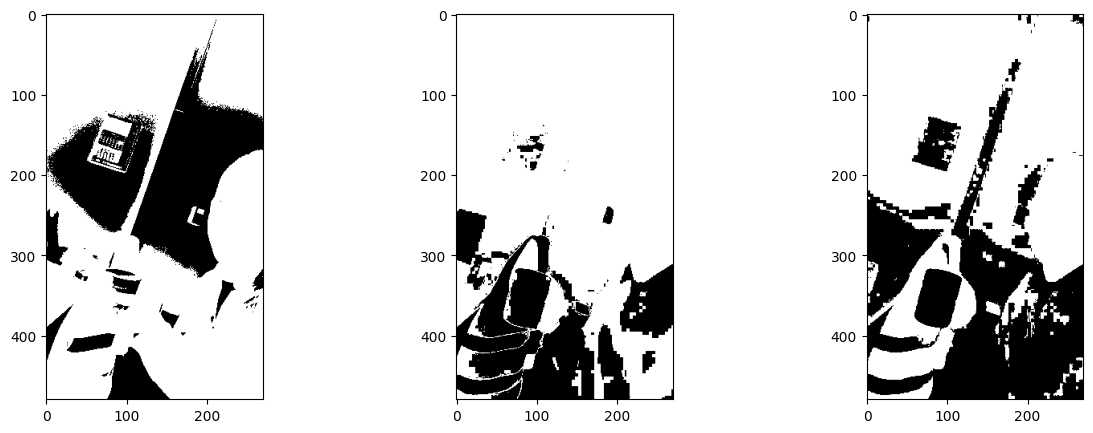

In [65]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(mask_y_, cmap='gray', vmin=0, vmax=255)
ax[1].imshow(mask_cb, cmap='gray', vmin=0, vmax=255)
ax[2].imshow(mask_cr, cmap='gray', vmin=0, vmax=255)  # vmin=0, vmax=255 settings to show white pictures in

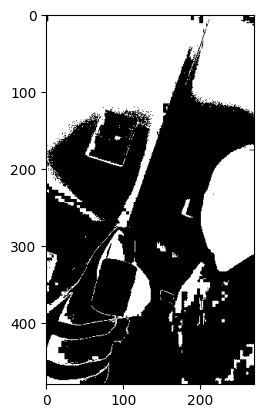

In [66]:
plt.imshow(mask_ycbcr, cmap='gray')

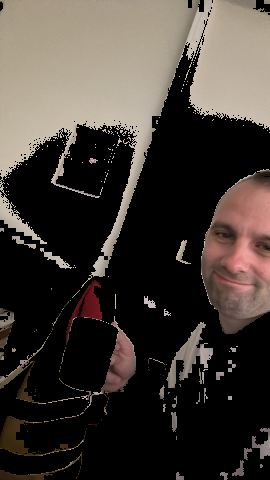

In [67]:
y_cbcr_mask= use_the_mask(img_1, mask_ycbcr)
y_cbcr_mask

## Skin detection in rg chromaticity

In [138]:
# Open images with PIL
with Image.open(img_1_path) as img_1:
  img_1.load()

img_1 = img_1.reduce(4)

In [139]:
def rgb_to_RGB(image):
  image = np.array(image, dtype=np.float32)
  r,g,b = image[:,:,0], image[:,:,1], image[:,:,2]
  epsilon = 1e-6
  sum_rgb = r + g + b + epsilon
  red =  r / sum_rgb
  green =  g / sum_rgb

  return red, green

In [140]:
red, green = rgb_to_RGB(img_1)

In [141]:
one_matrix = np.ones(shape=red.shape, dtype=np.float32)
chrom = one_matrix - (red + green)

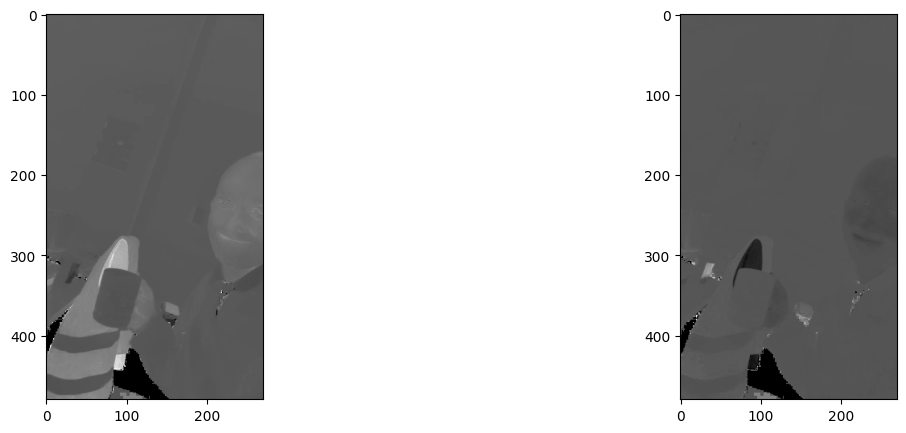

In [142]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(red, cmap="gray")
ax[1].imshow(green, cmap="gray")
plt.show()

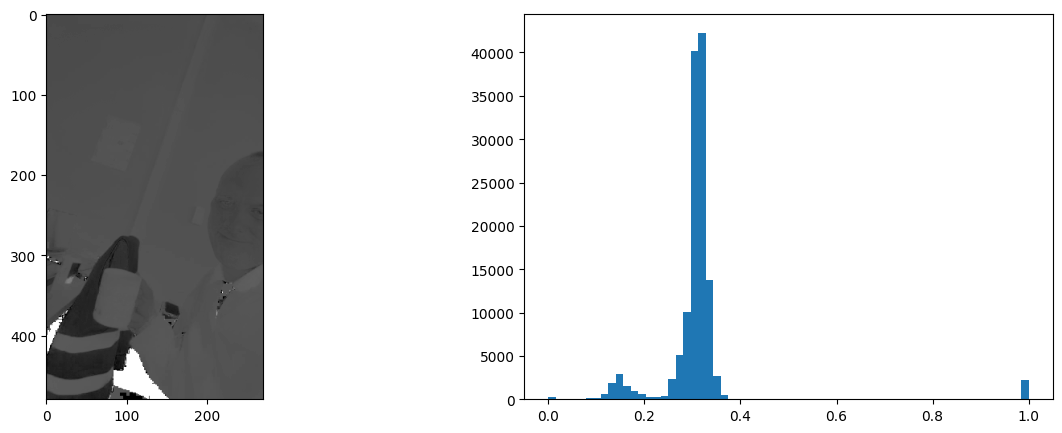

In [143]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(chrom, cmap="gray")
ax[1].hist(chrom.ravel(), bins=64)
plt.show()

In [144]:
face = chrom[200:310, 220:250]
face_r = red[200:310, 220:250]
face_g = green[200:310, 220:250]

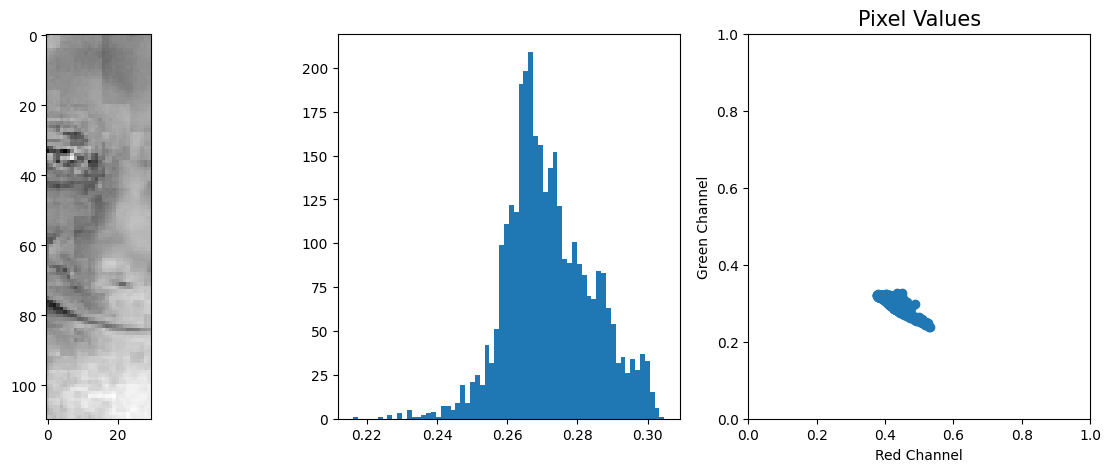

In [145]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(face, cmap="gray")
ax[1].hist(face.ravel(), bins=64)
ax[2].scatter(face_r, face_g)
ax[2].set_title('Pixel Values',fontsize=15)
ax[2].set_xlabel('Red Channel',fontsize=10)
ax[2].set_ylabel('Green Channel',fontsize=10)
ax[2].set_xlim(0,1)
ax[2].set_ylim(0,1)
plt.show()

In [181]:
face_std = np.std(face)
face_mean = np.mean(face)
face_std, face_mean

(0.012239809, 0.27201146)

In [182]:
def gaussian(p,mean,std):
    return np.exp(-(p-mean)**2/(2*std**2))*(1/(std*((2*np.pi)**0.5)))

In [183]:
gaussian_face = gaussian(chrom, face_mean, face_std)

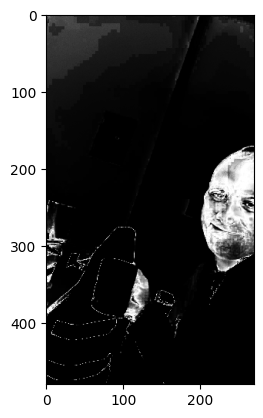

In [184]:
plt.imshow(gaussian_face, cmap="gray")
plt.show()

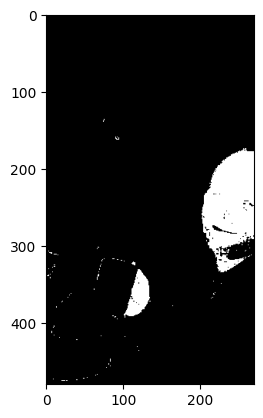

In [185]:
binarized_mask = final_mask > final_mask.mean()
plt.imshow(binarized_mask, cmap='gray')

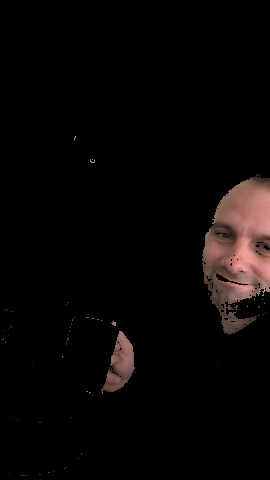

In [186]:
use_the_mask(img_1, binarized_mask)

In [171]:
face_std_r = np.std(face_r)
face_mean_r = np.mean(face_r)
face_std_r, face_mean_r

(0.021505084, 0.43109074)

In [172]:
face_std_g = np.std(face_g)
face_mean_g = np.mean(face_g)
face_std_g, face_mean_g

(0.012554458, 0.2968978)

In [173]:
gaussian_face_r = gaussian(red, face_mean_r, face_std_r)
gaussian_face_g = gaussian(green, face_mean_g, face_std_g)

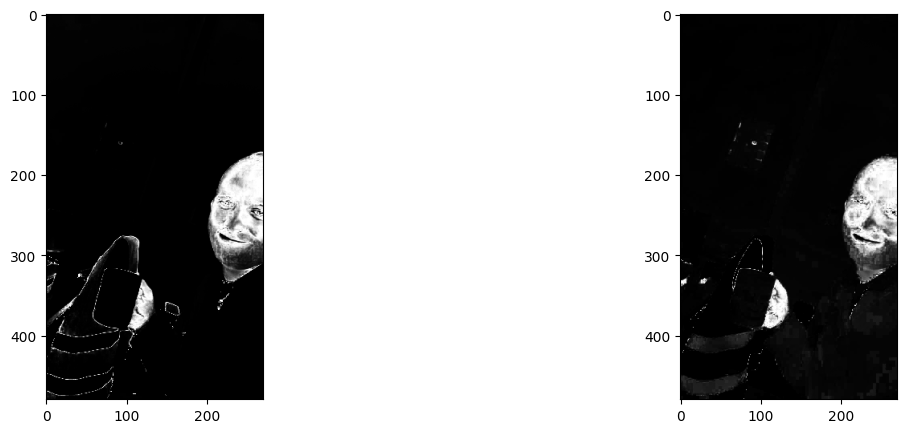

In [180]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(gaussian_face_r, cmap="gray")
ax[1].imshow(gaussian_face_g, cmap="gray")
plt.show()

In [176]:
final_mask = gaussian_face_r * gaussian_face_g

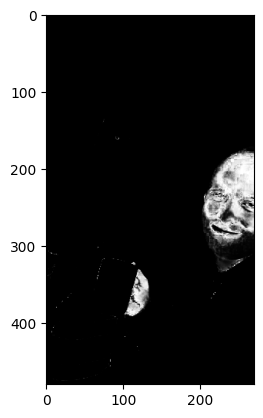

In [177]:
plt.imshow(final_mask, cmap="gray")
plt.show()

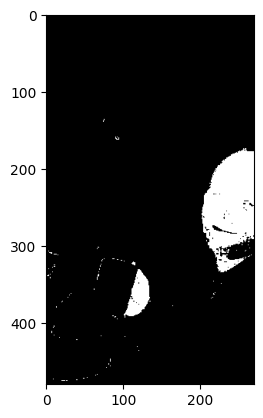

In [178]:
binarized_mask = final_mask > final_mask.mean()
plt.imshow(binarized_mask, cmap='gray')

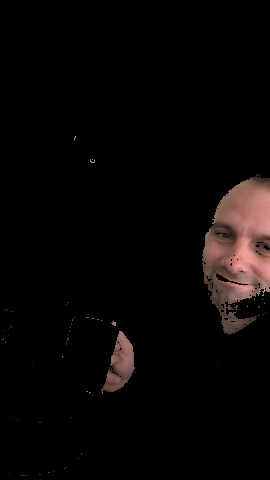

In [179]:
rg_chrom_mask = use_the_mask(img_1, binarized_mask)
rg_chrom_mask